In [ ]:
%pip install boto3 awscli

In [1]:
import os
import boto3

# Xoá env var AWS cũ trong kernel (env var được ưu tiên hơn ~/.aws/credentials,
# nếu kernel giữ key cũ sẽ gây InvalidAccessKeyId dù file credentials đúng)
for var in ("AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN", "AWS_PROFILE"):
    os.environ.pop(var, None)

bucket = "agent-force-video-bucket"
prefix = "dataset/keyframes/L21/"

session = boto3.Session(profile_name="default")
s3 = session.client("s3")

# Verify credentials
print(session.client("sts").get_caller_identity()["Arn"])

arn:aws:iam::884087662721:user/truongnguyen


In [2]:
# Liệt kê toàn bộ key (dùng paginator vì list_objects_v2 chỉ trả tối đa 1000 object/lần)
keys = []
paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    keys.extend(obj["Key"] for obj in page.get("Contents", []))

print(f"Tổng: {len(keys)} objects")
keys[:10]

Tổng: 7800 objects


['dataset/keyframes/L21/L21_V001/001.jpg',
 'dataset/keyframes/L21/L21_V001/002.jpg',
 'dataset/keyframes/L21/L21_V001/003.jpg',
 'dataset/keyframes/L21/L21_V001/004.jpg',
 'dataset/keyframes/L21/L21_V001/005.jpg',
 'dataset/keyframes/L21/L21_V001/006.jpg',
 'dataset/keyframes/L21/L21_V001/007.jpg',
 'dataset/keyframes/L21/L21_V001/008.jpg',
 'dataset/keyframes/L21/L21_V001/009.jpg',
 'dataset/keyframes/L21/L21_V001/010.jpg']

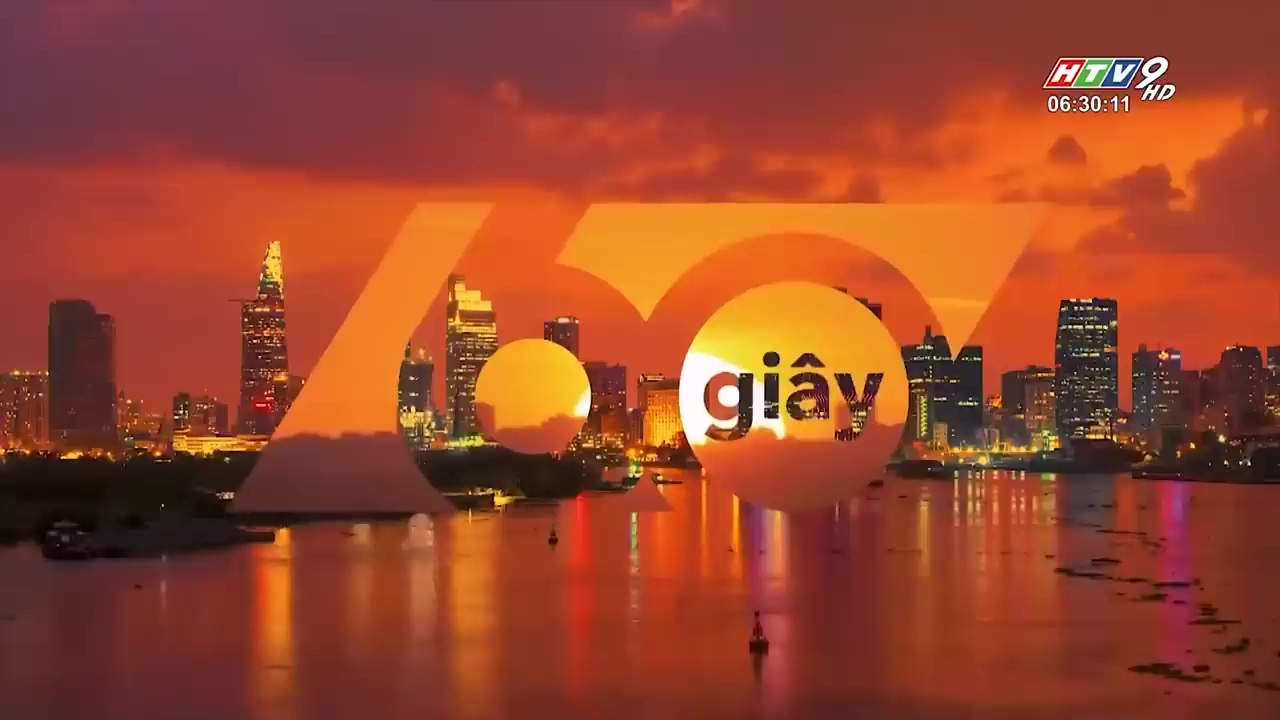

In [3]:
# Đọc 1 ảnh keyframe trực tiếp vào memory (không cần download ra file)
from PIL import Image
import io

obj = s3.get_object(Bucket=bucket, Key=keys[0])
img = Image.open(io.BytesIO(obj["Body"].read()))
img

In [ ]:
# Nếu là file CSV/parquet thì đọc thẳng bằng pandas (cần: pip install s3fs)
# import pandas as pd
# df = pd.read_csv(f"s3://{bucket}/dataset/metadata.csv")

# Hoặc download hẳn 1 file về local:
# s3.download_file(bucket, keys[0], "local_file.jpg")